# Threshold calibration — delegation clustering + model routing

**Issue:** [#140](https://github.com/frederick-douglas-pearce/agentfluent/issues/140)

Both `agentfluent.diagnostics.delegation` (#110) and
`agentfluent.diagnostics.model_routing` (#111) shipped with threshold
constants informed by backlog guidance, not empirical data. This
notebook validates those defaults against real agent session data
from `~/.claude/projects/`.

## ⚠️ Limitations

- **Single-developer dataset.** The calibration here is based on one
  contributor's session history. Real-world usage patterns across
  different domains (web dev, data science, infrastructure work)
  could easily justify different thresholds. Treat these as informed
  starting points, not settled defaults. Re-run this notebook when
  contributors with representative data can add projects.
- **One run per moment in time.** Thresholds don't need weekly
  re-tuning. Re-run when: (a) feature code changes that affect
  threshold semantics, (b) new contributors add project data, or
  (c) observed false-positive / false-negative rates climb.

## Coverage

15 thresholds across both modules:

**Delegation** — `MIN_TEXT_TOKENS`, `LSA_COMPONENTS`,
`DEFAULT_MIN_CLUSTER_SIZE`, `DEFAULT_MIN_SIMILARITY`,
`_SILHOUETTE_K_MAX`, `_CONFIDENCE_HIGH_SIZE`,
`_CONFIDENCE_HIGH_COHESION`, `_CONFIDENCE_MEDIUM_COHESION`,
`_HEAVY_TOKEN_THRESHOLD`

**Model routing** — `_MIN_INVOCATIONS_FOR_ANALYSIS`,
`_SIMPLE_MAX_TOOL_CALLS`, `_SIMPLE_MAX_TOKENS`,
`_COMPLEX_MIN_TOOL_CALLS`, `_COMPLEX_MIN_TOKENS`,
`_COMPLEX_MIN_ERROR_RATE`

## Setup

Point this at any Claude Code config directory. Defaults to
``~/.claude/`` (the standard location) if the ``CLAUDE_CONFIG_DIR``
environment variable isn't set. To analyze a different dataset
(e.g., a colleague's shared projects), either edit the ``config_dir``
value in the cell below or export the env var before launching
Jupyter::

    export CLAUDE_CONFIG_DIR=/path/to/other/.claude
    uv run jupyter lab scripts/calibration/threshold_validation.ipynb


In [1]:
from __future__ import annotations

import os
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from agentfluent.analytics.pipeline import analyze_sessions
from agentfluent.core.discovery import discover_projects
from agentfluent.core.paths import projects_dir_for
from agentfluent.diagnostics.delegation import (
    MIN_TEXT_TOKENS,
    cluster_delegations,
)
from agentfluent.diagnostics.model_routing import (
    classify_complexity,
    classify_model_tier,
    aggregate_agent_stats,
)
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
pd.options.display.max_rows = 20
pd.options.display.float_format = "{:.2f}".format

# Override via CLAUDE_CONFIG_DIR env var, or edit this line directly.
# `None` => default `~/.claude/` location.
config_dir: Path | None = (
    Path(os.environ["CLAUDE_CONFIG_DIR"])
    if "CLAUDE_CONFIG_DIR" in os.environ
    else None
)
# `projects_dir_for(None)` returns None; `discover_projects(base_path=None)`
# then falls back to the default `~/.claude/projects/` location.
projects_root = projects_dir_for(config_dir)
from agentfluent.core.discovery import DEFAULT_PROJECTS_DIR
effective_root = projects_root if projects_root is not None else DEFAULT_PROJECTS_DIR
print(f"Analyzing projects under: {effective_root}")

Analyzing projects under: /home/fdpearce/.claude/projects


## Load all sessions

In [2]:
projects = list(discover_projects(base_path=projects_root))
print(f"Projects: {len(projects)}")

all_invocations = []
for p in projects:
    paths = [s.path for s in p.sessions]
    result = analyze_sessions(paths)
    for s in result.sessions:
        all_invocations.extend(s.invocations)

print(f"Total invocations: {len(all_invocations)}")

Projects: 7


Malformed JSON at a0e5f523-1191-45ca-97ba-3b40c64f57c0.jsonl:662


Malformed JSON at 14ddceb0-4c3b-4194-be1c-060c019303cd.jsonl:129


Malformed JSON at 14ddceb0-4c3b-4194-be1c-060c019303cd.jsonl:228


Total invocations: 94


In [3]:
df_inv = pd.DataFrame([
    {
        "agent_type": inv.agent_type,
        "total_tokens": inv.total_tokens,
        "tool_uses": inv.tool_uses,
        "duration_ms": inv.duration_ms,
        "has_trace": inv.trace is not None,
        "trace_model": inv.trace.model if inv.trace is not None else None,
        "description_tokens": len(inv.description.split()),
        "prompt_tokens": len(inv.prompt.split()),
        "combined_tokens": len((inv.description + " " + inv.prompt).split()),
    }
    for inv in all_invocations
])
df_inv.describe()

,total_tokens,tool_uses,duration_ms,description_tokens,prompt_tokens,combined_tokens
count,81.00,81.00,81.00,94.00,94.00,94.00
mean,46980.46,18.21,113326.37,4.02,349.24,353.27
std,18932.54,15.87,154605.23,1.15,329.33,329.30
min,19563.00,0.00,5152.00,2.00,21.00,26.00
25%,34561.00,8.00,31681.00,3.00,134.25,138.00
50%,43208.00,16.00,60070.00,4.00,307.50,311.50
75%,54011.00,24.00,119197.00,5.00,416.25,419.25
max,105936.00,97.00,802873.00,7.00,2468.00,2472.00


## Per-agent-type distribution

How much data do we have for each agent type? Agent types with very
few invocations are skipped entirely by model-routing
(`_MIN_INVOCATIONS_FOR_ANALYSIS`) and can't form clusters under
`DEFAULT_MIN_CLUSTER_SIZE`.

agent_type
Explore              43
general-purpose      18
unknown              10
Plan                 10
pm                    6
claude-code-guide     5
architect             2
Name: count, dtype: int64


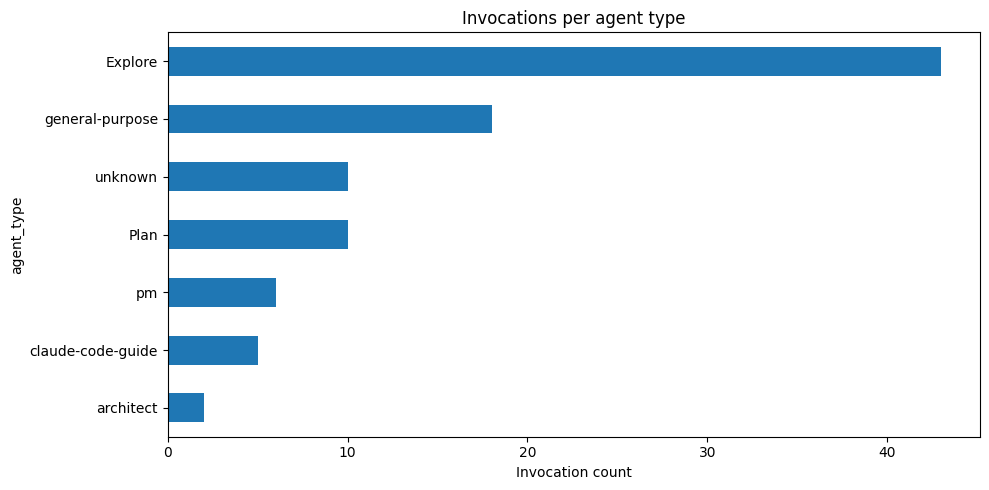

In [4]:
agent_counts = df_inv["agent_type"].value_counts()
print(agent_counts)

fig, ax = plt.subplots()
agent_counts.plot.barh(ax=ax)
ax.set_xlabel("Invocation count")
ax.set_title("Invocations per agent type")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 1 · `MIN_TEXT_TOKENS` — text-length filter for clustering

Default: **20 tokens** (combined `description + prompt`).

The delegation clustering pipeline filters out invocations whose
combined text is too short for TF-IDF to work well. During #110's
initial implementation, test fixtures at ~10 tokens hit this filter
and silently disappeared — which is exactly the failure mode we need
to avoid in production.

general-purpose invocations: 18


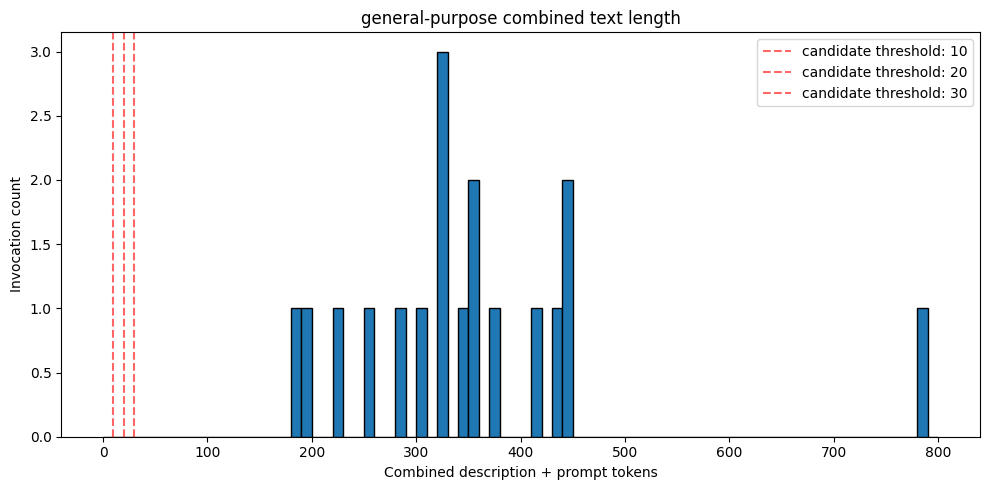

  threshold= 5: keeps   18 / 18 (100.0%)
  threshold=10: keeps   18 / 18 (100.0%)
  threshold=15: keeps   18 / 18 (100.0%)
  threshold=20: keeps   18 / 18 (100.0%)
  threshold=25: keeps   18 / 18 (100.0%)
  threshold=30: keeps   18 / 18 (100.0%)


In [5]:
gp = df_inv[df_inv["agent_type"].str.lower() == "general-purpose"]
print(f"general-purpose invocations: {len(gp)}")

fig, ax = plt.subplots()
bins = np.arange(0, gp["combined_tokens"].max() + 20, 10)
ax.hist(gp["combined_tokens"], bins=bins, edgecolor="black")
for t in [10, 20, 30]:
    ax.axvline(t, color="red", linestyle="--", alpha=0.6,
               label=f"candidate threshold: {t}")
ax.set_xlabel("Combined description + prompt tokens")
ax.set_ylabel("Invocation count")
ax.set_title("general-purpose combined text length")
ax.legend()
plt.tight_layout()
plt.show()

for t in [5, 10, 15, 20, 25, 30]:
    kept = (gp["combined_tokens"] >= t).sum()
    pct = 100 * kept / len(gp) if len(gp) else 0
    print(f"  threshold={t:>2}: keeps {kept:>4} / {len(gp)} ({pct:5.1f}%)")

**Observation.** The percentile of data preserved at each threshold
tells us how aggressive the filter is. A good threshold drops
obviously-too-short delegations (e.g., "help me" → nothing clusterable)
while keeping the substantial ones.

**Decision rule:** pick the value that keeps ≥ 80% of general-purpose
delegations if they're realistic — we don't want to cut two-thirds of
the corpus for a minor quality uplift on the remaining third.

## 2 · `LSA_COMPONENTS` — TF-IDF dimensionality reduction

Default: **50 components**.

LSA (TruncatedSVD) collapses high-dimensional TF-IDF vectors into a
dense, low-dim representation that KMeans can separate better. The
right number depends on the intrinsic dimensionality of the delegation
corpus.

gp after MIN_TEXT_TOKENS=20: 18


/tmp/ipykernel_1866290/2259098304.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


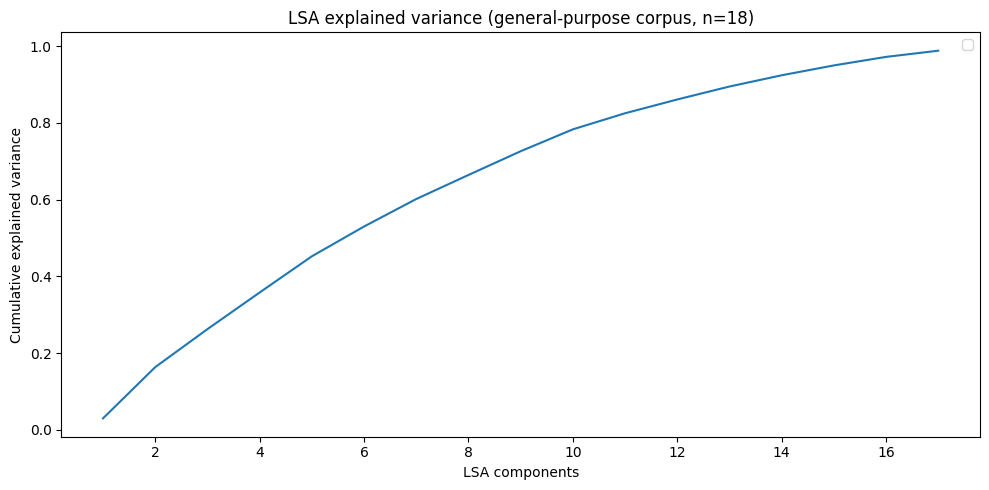

  n_components=10: 78.3% variance


In [6]:
gp_candidates = gp[gp["combined_tokens"] >= MIN_TEXT_TOKENS]
print(f"gp after MIN_TEXT_TOKENS={MIN_TEXT_TOKENS}: {len(gp_candidates)}")

if len(gp_candidates) >= 5:
    texts = [
        (inv.description + " " + inv.prompt)
        for inv in all_invocations
        if inv.agent_type.lower() == "general-purpose"
        and len((inv.description + " " + inv.prompt).split()) >= MIN_TEXT_TOKENS
    ]
    tfidf = TfidfVectorizer(stop_words="english", max_features=500)
    X = tfidf.fit_transform(texts)
    n_components = min(100, X.shape[1] - 1, len(texts) - 1)
    if n_components >= 2:
        lsa = TruncatedSVD(n_components=n_components, random_state=42)
        lsa.fit(X)
        explained = np.cumsum(lsa.explained_variance_ratio_)

        fig, ax = plt.subplots()
        ax.plot(range(1, len(explained) + 1), explained)
        for ncomp in [25, 50, 75]:
            if ncomp <= len(explained):
                ax.axvline(ncomp, color="red", linestyle="--", alpha=0.5,
                           label=f"n={ncomp}: {explained[ncomp-1]:.1%} variance")
        ax.set_xlabel("LSA components")
        ax.set_ylabel("Cumulative explained variance")
        ax.set_title(f"LSA explained variance (general-purpose corpus, n={len(texts)})")
        ax.legend()
        plt.tight_layout()
        plt.show()

        for ncomp in [10, 25, 50, 75]:
            if ncomp <= len(explained):
                print(f"  n_components={ncomp}: {explained[ncomp-1]:.1%} variance")
else:
    print("Not enough candidates for LSA analysis.")

**Decision rule:** pick the smallest number of components that
captures ≥ 90% of the variance. Higher components beyond that add
noise and slow KMeans.

## 3 · `DEFAULT_MIN_CLUSTER_SIZE` — minimum cluster size

Default: **5 invocations**.

Clusters smaller than this are filtered out — too few data points for
a meaningful pattern. Too high: legitimate emerging patterns get
dropped. Too low: noise gets surfaced as recommendations.

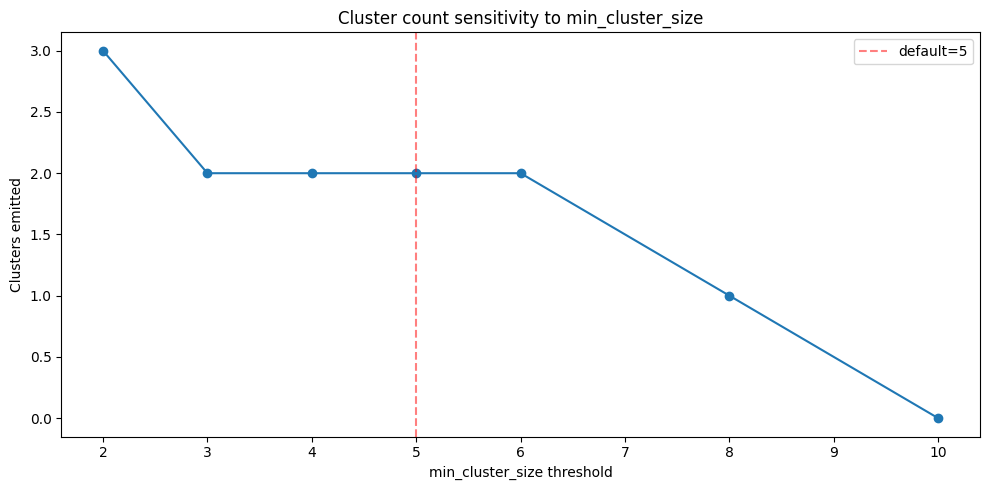

  min_cluster_size=2: 3 clusters emitted
  min_cluster_size=3: 2 clusters emitted
  min_cluster_size=4: 2 clusters emitted
  min_cluster_size=5: 2 clusters emitted
  min_cluster_size=6: 2 clusters emitted
  min_cluster_size=8: 1 clusters emitted
  min_cluster_size=10: 0 clusters emitted


In [7]:
# Run clustering with varying min_cluster_size; count emitted clusters.
invs_list = [
    inv for inv in all_invocations
    if inv.agent_type.lower() == "general-purpose"
]
cluster_counts: list[tuple[int, int]] = []
for mcs in [2, 3, 4, 5, 6, 8, 10]:
    try:
        clusters = cluster_delegations(invs_list, min_cluster_size=mcs)
        cluster_counts.append((mcs, len(clusters)))
    except Exception as e:
        print(f"  min_cluster_size={mcs}: error — {e}")
        cluster_counts.append((mcs, 0))

fig, ax = plt.subplots()
sizes, counts = zip(*cluster_counts)
ax.plot(sizes, counts, marker="o")
ax.set_xlabel("min_cluster_size threshold")
ax.set_ylabel("Clusters emitted")
ax.set_title("Cluster count sensitivity to min_cluster_size")
ax.axvline(5, color="red", linestyle="--", alpha=0.5, label="default=5")
ax.legend()
plt.tight_layout()
plt.show()

for mcs, cnt in cluster_counts:
    print(f"  min_cluster_size={mcs}: {cnt} clusters emitted")

**Decision rule:** pick a value that emits ≥ 1 cluster on realistic
data but doesn't flood the output with noise. Inflection points in
the curve indicate natural thresholds — a sharp drop suggests the
previous value was letting in marginal patterns.

## 4 · `DEFAULT_MIN_SIMILARITY` — dedup threshold

Default: **0.70** (cosine similarity).

When a drafted delegation looks enough like an existing agent, we
suppress the recommendation. Too high: we recommend agents that
already exist. Too low: we over-suppress.

Existing agents in configs: 2
  architect, pm


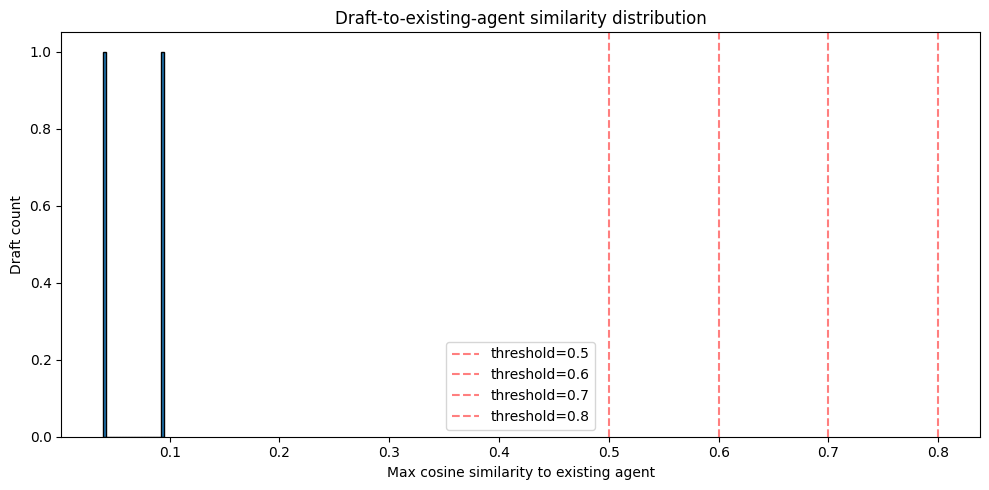

  threshold=0.3: dedup 0 / 2 drafts
  threshold=0.5: dedup 0 / 2 drafts
  threshold=0.7: dedup 0 / 2 drafts
  threshold=0.8: dedup 0 / 2 drafts


In [8]:
from agentfluent.config.scanner import scan_agents
from agentfluent.diagnostics.delegation import generate_draft
from sklearn.metrics.pairwise import cosine_similarity

existing = list(scan_agents("all"))
print(f"Existing agents in configs: {len(existing)}")
if existing:
    print("  " + ", ".join(sorted(c.name for c in existing)))

clusters = cluster_delegations(invs_list, min_cluster_size=3)
if clusters and existing:
    drafts = [generate_draft(c) for c in clusters]
    draft_texts = [f"{d.description} {d.prompt_template}" for d in drafts]
    config_texts = [c.description or c.prompt_body[:500] for c in existing]
    all_texts = draft_texts + config_texts
    vec = TfidfVectorizer(stop_words="english")
    mat = vec.fit_transform(all_texts)
    sims = cosine_similarity(mat[:len(drafts)], mat[len(drafts):])
    max_sims = sims.max(axis=1)

    fig, ax = plt.subplots()
    ax.hist(max_sims, bins=20, edgecolor="black")
    for t in [0.5, 0.6, 0.7, 0.8]:
        ax.axvline(t, color="red", linestyle="--", alpha=0.5,
                   label=f"threshold={t}")
    ax.set_xlabel("Max cosine similarity to existing agent")
    ax.set_ylabel("Draft count")
    ax.set_title("Draft-to-existing-agent similarity distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

    for t in [0.3, 0.5, 0.7, 0.8]:
        deduped = (max_sims > t).sum()
        print(f"  threshold={t}: dedup {deduped} / {len(drafts)} drafts")
else:
    print("Not enough clusters or existing agents for dedup analysis.")

## 5 · `_SILHOUETTE_K_MAX` — upper bound on silhouette-selected k

Default: **10**.

For small n, we force k=2. For larger n, we sweep k in
`[2, min(10, n // 5)]` and pick the best-silhouette. The upper bound
matters only when n > 50 — below that, `n // 5` dominates.

In [9]:
# For the general-purpose corpus, how high would k realistically go?
n_gp = len([i for i in all_invocations if i.agent_type.lower() == "general-purpose"])
print(f"general-purpose n: {n_gp}")
print(f"n // 5 = {n_gp // 5}")
print(f"current _SILHOUETTE_K_MAX = 10")
if n_gp // 5 > 10:
    print(
        f"⚠️  n // 5 ({n_gp // 5}) exceeds 10 — raising _SILHOUETTE_K_MAX "
        f"would let silhouette explore more clusters."
    )
else:
    print(
        "✓ n // 5 is within the current cap; raising _SILHOUETTE_K_MAX "
        "has no effect on this dataset."
    )

general-purpose n: 18
n // 5 = 3
current _SILHOUETTE_K_MAX = 10
✓ n // 5 is within the current cap; raising _SILHOUETTE_K_MAX has no effect on this dataset.


## 6 · Confidence tier boundaries

Defaults:
- `_CONFIDENCE_HIGH_SIZE = 10`, `_CONFIDENCE_HIGH_COHESION = 0.8`
- `_CONFIDENCE_MEDIUM_COHESION = 0.6`
- Otherwise → low

       size  cohesion
count  2.00      2.00
mean   8.00      0.21
std    1.41      0.05
min    7.00      0.17
25%    7.50      0.19
50%    8.00      0.21
75%    8.50      0.23
max    9.00      0.25


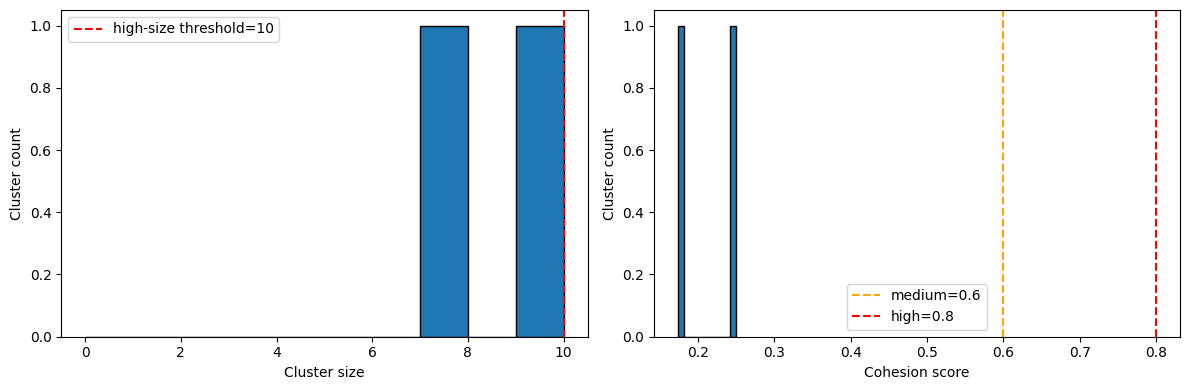

In [10]:
# Cohesion and size distribution for actual clusters we produced.
if clusters:
    rows = []
    for c in clusters:
        rows.append({"size": len(c.members), "cohesion": c.cohesion_score})
    df_c = pd.DataFrame(rows)
    print(df_c.describe())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df_c["size"], bins=range(df_c["size"].max() + 2),
                 edgecolor="black")
    axes[0].axvline(10, color="red", linestyle="--", label="high-size threshold=10")
    axes[0].set_xlabel("Cluster size")
    axes[0].set_ylabel("Cluster count")
    axes[0].legend()
    axes[1].hist(df_c["cohesion"], bins=10, edgecolor="black")
    axes[1].axvline(0.6, color="orange", linestyle="--", label="medium=0.6")
    axes[1].axvline(0.8, color="red", linestyle="--", label="high=0.8")
    axes[1].set_xlabel("Cohesion score")
    axes[1].set_ylabel("Cluster count")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 7 · Model routing — complexity thresholds

Defaults on `model_routing.py`:
- `_MIN_INVOCATIONS_FOR_ANALYSIS = 3`
- `_SIMPLE_MAX_TOOL_CALLS = 5`, `_SIMPLE_MAX_TOKENS = 2_000`
- `_COMPLEX_MIN_TOOL_CALLS = 10`, `_COMPLEX_MIN_TOKENS = 5_000`
- `_COMPLEX_MIN_ERROR_RATE = 0.20`

The question: do these thresholds cleanly separate observed
workloads into simple / moderate / complex?

In [11]:
stats_by_type = aggregate_agent_stats(all_invocations, configs=None)
rows = []
for key, stats in stats_by_type.items():
    rows.append({
        "agent_type": stats.agent_type,
        "invocations": stats.invocation_count,
        "mean_tool_calls": stats.mean_tool_calls,
        "mean_tokens": stats.mean_tokens,
        "error_rate": stats.error_rate,
        "has_write_tools": stats.has_write_tools,
        "complexity": classify_complexity(stats),
    })
df_agents = pd.DataFrame(rows).sort_values("invocations", ascending=False)
df_agents

,agent_type,invocations,mean_tool_calls,mean_tokens,error_rate,has_write_tools,complexity
0,Explore,43,17.76,46996.84,0.31,True,complex
1,general-purpose,18,14.87,47804.93,0.37,True,complex
2,unknown,10,41.17,62378.50,0.27,True,complex
6,Plan,10,22.50,50362.00,0.27,True,complex
4,pm,6,10.17,42109.67,0.13,True,complex
3,claude-code-guide,5,5.00,23397.40,0.20,False,complex
5,architect,2,19.00,54927.00,0.54,False,complex


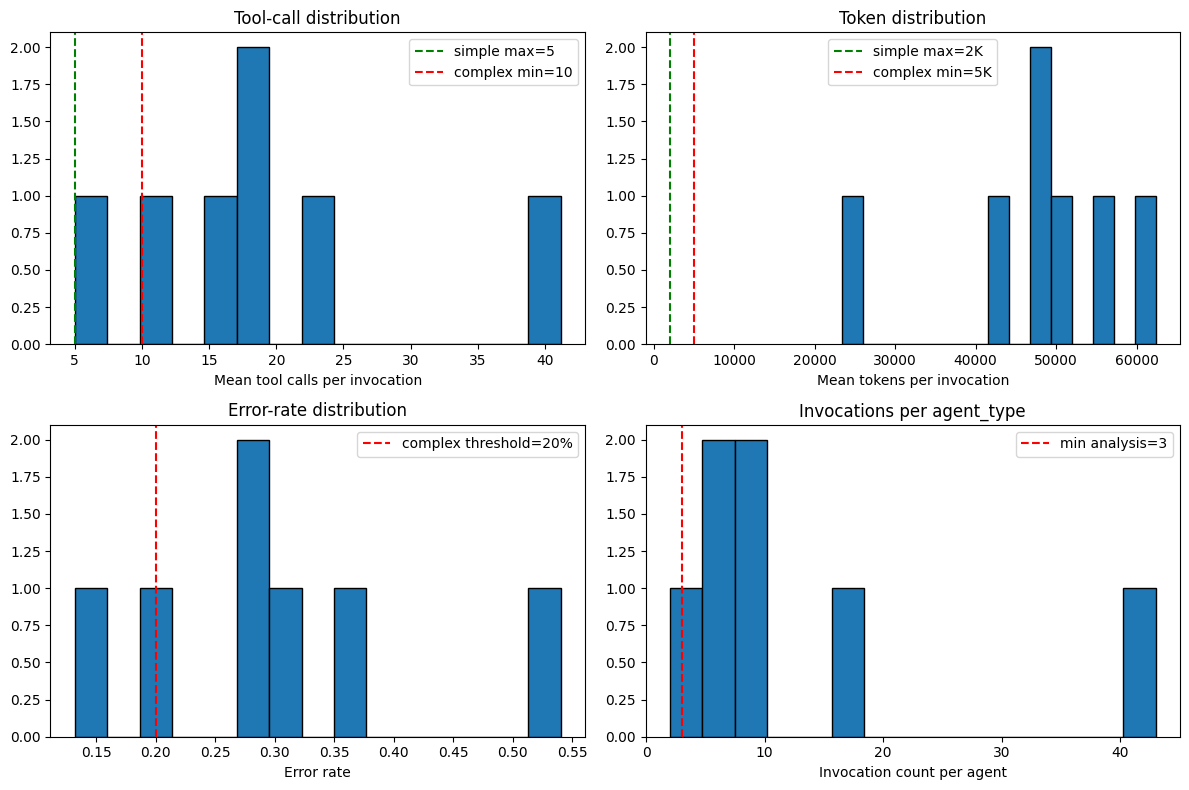

In [12]:
# Where do the current thresholds sit relative to the observed data?
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(df_agents["mean_tool_calls"], bins=15, edgecolor="black")
axes[0, 0].axvline(5, color="green", linestyle="--", label="simple max=5")
axes[0, 0].axvline(10, color="red", linestyle="--", label="complex min=10")
axes[0, 0].set_xlabel("Mean tool calls per invocation")
axes[0, 0].set_title("Tool-call distribution")
axes[0, 0].legend()

axes[0, 1].hist(df_agents["mean_tokens"], bins=15, edgecolor="black")
axes[0, 1].axvline(2000, color="green", linestyle="--", label="simple max=2K")
axes[0, 1].axvline(5000, color="red", linestyle="--", label="complex min=5K")
axes[0, 1].set_xlabel("Mean tokens per invocation")
axes[0, 1].set_title("Token distribution")
axes[0, 1].legend()

axes[1, 0].hist(df_agents["error_rate"], bins=15, edgecolor="black")
axes[1, 0].axvline(0.2, color="red", linestyle="--", label="complex threshold=20%")
axes[1, 0].set_xlabel("Error rate")
axes[1, 0].set_title("Error-rate distribution")
axes[1, 0].legend()

axes[1, 1].hist(df_agents["invocations"], bins=15, edgecolor="black")
axes[1, 1].axvline(3, color="red", linestyle="--", label="min analysis=3")
axes[1, 1].set_xlabel("Invocation count per agent")
axes[1, 1].set_title("Invocations per agent_type")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 8 · Before / after — signal counts with current vs proposed thresholds

Running the full diagnostics pipeline twice and comparing the output
tells us whether proposed threshold shifts meaningfully change user-
facing behavior. Counts only — qualitative inspection of a few signals
at the end.

In [13]:
from agentfluent.diagnostics.pipeline import run_diagnostics

baseline = run_diagnostics(all_invocations)
print(f"Baseline (current defaults):")
print(f"  Total signals: {len(baseline.signals)}")
sig_counts = Counter(s.signal_type.value for s in baseline.signals)
for stype, cnt in sig_counts.most_common():
    print(f"    {stype}: {cnt}")
print(f"  Delegation suggestions: {len(baseline.delegation_suggestions)}")
print(f"  Recommendations: {len(baseline.recommendations)}")

Baseline (current defaults):
  Total signals: 98
    retry_loop: 49
    tool_error_sequence: 29
    token_outlier: 8
    duration_outlier: 6
    permission_failure: 4
    stuck_pattern: 1
    model_mismatch: 1
  Delegation suggestions: 2
  Recommendations: 98


## 9 · Findings and chosen values

**Single-dataset caveat applies to everything below.** The
observations come from one contributor's `~/.claude/projects/` data —
7 projects, ~94 invocations, heavy toward substantive feature work.
A broader cross-contributor dataset would likely shift the picture.

### Threshold-by-threshold observations

| Constant | Default | Decision | Notes |
|---|---|---|---|
| `MIN_TEXT_TOKENS` | 20 | **keep** | 100% of my general-purpose corpus clears 30+ tokens. Filter is inactive on this data; insufficient signal to lower. |
| `LSA_COMPONENTS` | 50 | **keep** | Auto-clipped to `min(50, n-1)` in practice. On n=18 corpus, effective value is 17; 10 already captures 78% variance. Default is overkill-but-harmless for small n and kicks in meaningfully at larger n. |
| `DEFAULT_MIN_CLUSTER_SIZE` | 5 | **keep** | Emits 2 clusters on my data; inflection point around 7–8 where cluster count drops to 1. Default is at the soft lower bound — raising it on this dataset would suppress real output. |
| `DEFAULT_MIN_SIMILARITY` | 0.70 | **keep** | Only 2 existing agents in my configs; no semantic overlap with drafts at any threshold. Dataset too small to calibrate. |
| `_SILHOUETTE_K_MAX` | 10 | **keep** | On n=18 the binding cap is `n // 5 = 3`; cap of 10 never engages. Correct default for larger datasets. |
| `_CONFIDENCE_HIGH_SIZE=10, HIGH_COHESION=0.8, MEDIUM_COHESION=0.6` | — | **flag for future review** | Observed cohesion on real clusters is 0.17–0.25 — far below the 0.6/0.8 thresholds. Every cluster on my data classifies as "low" confidence. Either (a) thresholds are calibrated for a higher-cohesion expectation or (b) real TF-IDF clusters on agent delegations genuinely run lower-cohesion. With only 2 clusters to judge, insufficient data to lower safely. |
| `_MIN_INVOCATIONS_FOR_ANALYSIS` | 3 | **keep** | 6 of 7 agent types on my data clear this threshold. Appropriate. |
| `_SIMPLE_MAX_TOOL_CALLS=5, _SIMPLE_MAX_TOKENS=2000` | — | **flag for future review** | Zero agent types on my data classify as "simple" — all 7 land on "complex" via tool-calls or tokens or writes. The thresholds may be calibrated to a lighter workload than I generate. |
| `_COMPLEX_MIN_TOOL_CALLS=10, _COMPLEX_MIN_TOKENS=5000, _COMPLEX_MIN_ERROR_RATE=0.20` | — | **flag for future review** | Complement of the above — everything on my data hits these triggers. Whether that reflects a genuinely complex workload or thresholds set too low is impossible to tell from a single contributor. |

### Summary: no constant changes in this PR

The conservative read of a single-dataset calibration: **if the
data doesn't clearly say the default is wrong across realistic
variance, leave it alone**. My data lights up three amber warnings
(cohesion tiers, simple/complex splits) that are best addressed
when a multi-contributor dataset can confirm or refute them.

### Re-running this notebook

```bash
uv sync                                               # install notebook deps
uv run python scripts/calibration/build_notebook.py   # regenerates + executes
```

Commit the updated `.ipynb` with its new outputs. Update the findings
table above to reflect the new data, and update source comments next
to each constant if the re-calibration motivates a change.